In [10]:
import sys
!~/.local/bin/uv pip install --python {sys.executable} requests torch numpy matplotlib scipy --quiet

In [11]:
import struct
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import requests

In [ ]:
BUTTON_BITS = [
    0x8000, 0x4000, 0x2000, 0x1000,
    0x0800, 0x0400, 0x0200, 0x0100,
    0x0020, 0x0010, 0x0008, 0x0004, 0x0002, 0x0001,
]

# 5 output categories
CAT_NAMES = ["Directional", "A/B", "Z/L/R", "Start", "No Input"]
INPUT_DIM  = 5

# Which columns of the 16-col base tensor [stick_x, stick_y, A..CRight] map to each category
#   col 0  = stick_x   col 1  = stick_y
#   col 2  = A         col 3  = B
#   col 4  = Z         col 5  = Start
#   col 6  = DUp       col 7  = DDown    col 8  = DLeft   col 9  = DRight
#   col 10 = L         col 11 = R
#   col 12 = CUp       col 13 = CDown    col 14 = CLeft   col 15 = CRight
CAT_COLS = [
    [0, 1, 6, 7, 8, 9, 12, 13, 14, 15], # Directional (Stick + D-Pad + C-Buttons)
    [2, 3],                               # A/B
    [4, 10, 11],                          # Z/L/R
    [5],                                  # Start
]


def parse_m64(raw: bytes) -> torch.Tensor:
    """Parse .m64 bytes into a (T, 5) binary float32 tensor — one column per category.
    Categories: [Directional, A/B, Z/L/R, Start, No Input]
    """
    version = struct.unpack_from("<I", raw, 0x004)[0]
    data_start = 0x200 if version in (1, 2) else 0x400
    num_samples = struct.unpack_from("<I", raw, 0x018)[0]

    buf = np.frombuffer(
        raw[data_start : data_start + num_samples * 4], dtype=np.uint8
    ).reshape(num_samples, 4)

    y_axis  = buf[:, 0].view(np.int8)
    x_axis  = buf[:, 1].view(np.int8)
    btn_raw = buf[:, 2].astype(np.uint16) * 256 + buf[:, 3].astype(np.uint16)
    buttons = np.stack(
        [(btn_raw & bit).astype(bool) for bit in BUTTON_BITS], axis=1
    ).astype(np.float32)

    stick_x = torch.from_numpy((x_axis != 0).astype(np.float32)).unsqueeze(1)
    stick_y = torch.from_numpy((y_axis != 0).astype(np.float32)).unsqueeze(1)
    btns    = torch.from_numpy(buttons)
    base    = torch.cat([stick_x, stick_y, btns], dim=1)  # (T, 16)

    cat_active = torch.stack(
        [base[:, cols].any(dim=1) for cols in CAT_COLS], dim=1
    ).float()  # (T, 4)

    no_input = (~cat_active.any(dim=1)).unsqueeze(1).float()
    return torch.cat([cat_active, no_input], dim=1)  # (T, 5)


def load_m64(source: str, cache_dir: str = ".") -> torch.Tensor:
    """Load an .m64 from a local path or URL, caching downloads locally."""
    if source.startswith("http://") or source.startswith("https://"):
        cache_path = Path(cache_dir) / Path(source).name
        if not cache_path.exists():
            print(f"Downloading {source} ...")
            cache_path.write_bytes(requests.get(source).content)
        raw = cache_path.read_bytes()
    else:
        raw = Path(source).read_bytes()
    return parse_m64(raw)

In [ ]:
def expand_to_sequential(frames: torch.Tensor) -> torch.Tensor:
    """Convert (T, 5) multi-hot frames to (N, 5) sequential one-hot events.

    Each active category in a frame becomes its own entry in column order.
    A no-input frame → one one-hot vector at col 4.
    """
    events = []
    eye = torch.eye(INPUT_DIM)
    for frame in frames:
        for col in frame.nonzero(as_tuple=True)[0]:
            events.append(eye[col])
    return torch.stack(events)  # (N, 5)


class M64Dataset(Dataset):
    """Windowed one-hot matrix dataset over one or more .m64 files.

    Each item is a (window_size, 5) matrix of sequential one-hot event vectors,
    where each row is one input category event. Windows are drawn from the
    full sequential event stream concatenated across all source files.

    Args:
        sources:     list of local paths or URLs to .m64 files.
        window_size: number of one-hot events per sample matrix.
        cache_dir:   directory to cache downloaded files.
    """

    def __init__(self, sources: list[str], window_size: int = 64, cache_dir: str = "."):
        self.window_size = window_size
        self.file_names: list[str] = []
        events = []

        for file_idx, src in enumerate(sources):
            print(f"[{file_idx}] Loading: {src}")
            raw_frames = load_m64(src, cache_dir=cache_dir)
            events.append(expand_to_sequential(raw_frames))
            self.file_names.append(Path(src).name)

        self.data = torch.cat(events, dim=0)  # (total_events, 5)
        self.n_windows = len(self.data) - window_size + 1
        print(f"\nTotal events:  {len(self.data):,}")
        print(f"Total windows: {self.n_windows:,}")

    def __len__(self) -> int:
        return self.n_windows

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.data[idx : idx + self.window_size]  # (window_size, 5)

In [14]:
SOURCES = [
    "./120_stars.m64",
    "./70_stars.m64",
    "./big_bob_omb_on_the_summit.m64"
]

WINDOW_SIZE = 64   # one-hot events per input matrix
BATCH_SIZE  = 128

dataset = M64Dataset(SOURCES, window_size=WINDOW_SIZE)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

print(f"Batches per epoch: {len(loader):,}")

[0] Loading: ./120_stars.m64
[1] Loading: ./70_stars.m64
[2] Loading: ./big_bob_omb_on_the_summit.m64

Total events:  436,072
Total windows: 436,009
Batches per epoch: 3,407


In [ ]:
# Inspect one batch
batch = next(iter(loader))
print("batch shape:", batch.shape)   # (B, window_size, 5)
print("first matrix:\n", batch[0])
print()
print("Column layout:")
for i, name in enumerate(CAT_NAMES):
    print(f"  col {i} = {name}")

/var/folders/bh/rhh2hs6d1_b3nsmynmf4ktmr0000gn/T/ipykernel_47246/3039459278.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha="right")


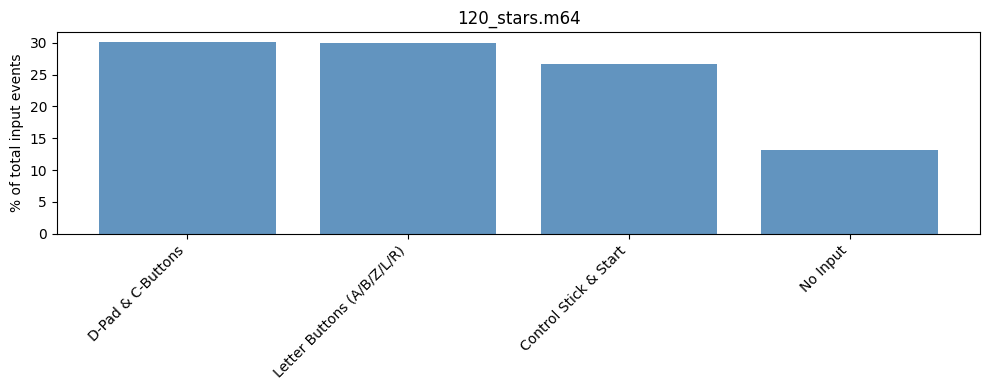

/var/folders/bh/rhh2hs6d1_b3nsmynmf4ktmr0000gn/T/ipykernel_47246/3039459278.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha="right")


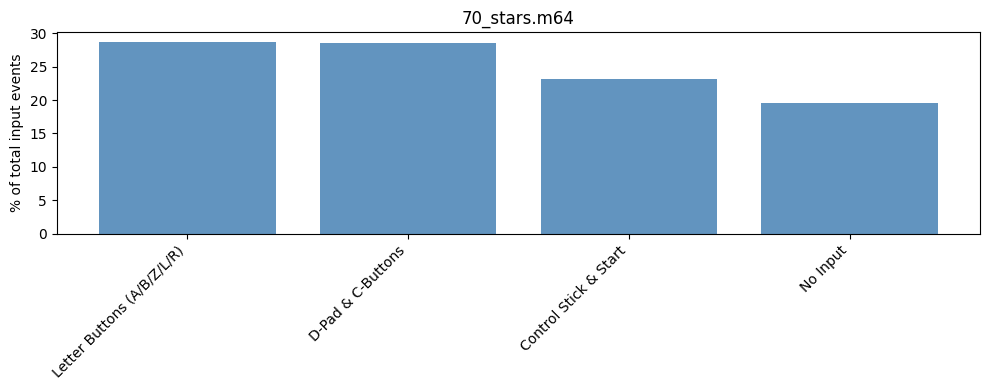

/var/folders/bh/rhh2hs6d1_b3nsmynmf4ktmr0000gn/T/ipykernel_47246/3039459278.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha="right")


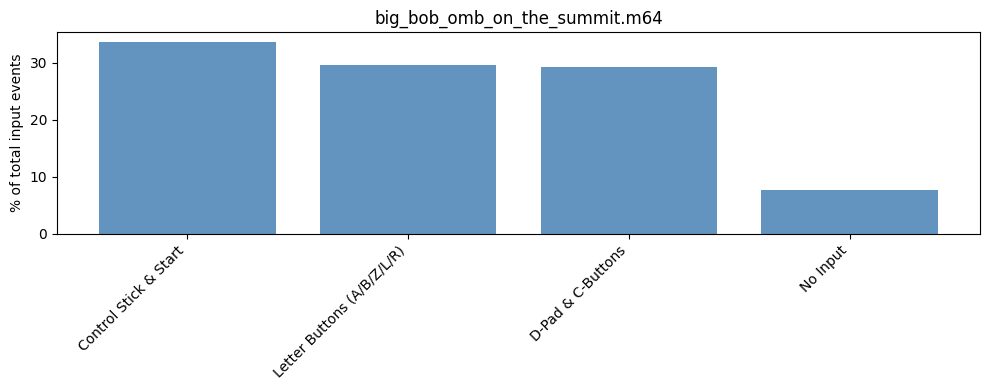

/var/folders/bh/rhh2hs6d1_b3nsmynmf4ktmr0000gn/T/ipykernel_47246/3039459278.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha="right")


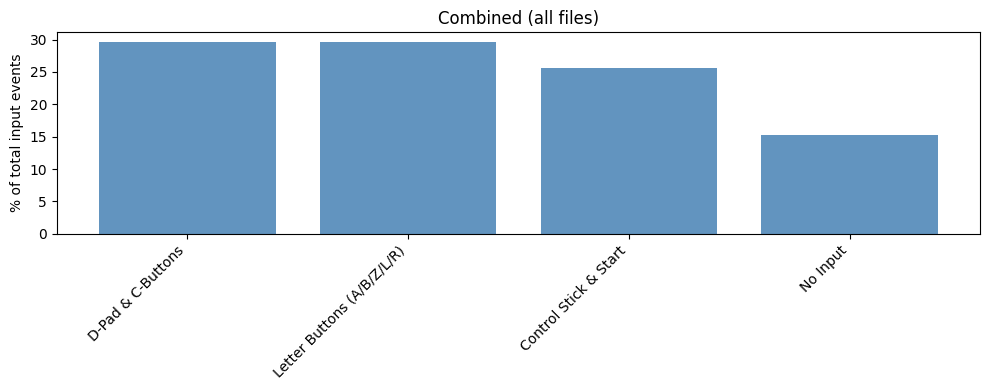

In [16]:
import matplotlib.pyplot as plt

def plot_activity(tensor, title):
    counts = tensor.sum(dim=0)
    pct    = counts / counts.sum() * 100

    # Sort descending so highest bar is on the left
    order  = pct.argsort(descending=True)
    names  = [CAT_NAMES[i] for i in order]
    values = pct[order].numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(names, values, color="steelblue", alpha=0.85)
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_ylabel("% of total input events")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

offset = 0
for name, src in zip(dataset.file_names, SOURCES):
    n = expand_to_sequential(load_m64(src)).shape[0]
    plot_activity(dataset.data[offset : offset + n], name)
    offset += n

plot_activity(dataset.data, "Combined (all files)")

In [17]:
def entropy_bits(tensor: torch.Tensor) -> float:
    """Expected number of bits to encode one draw from the category distribution."""
    probs = tensor.sum(dim=0) / len(tensor)
    probs = probs[probs > 0]
    return -(probs * probs.log2()).sum().item()

uniform_entropy = torch.log2(torch.tensor(INPUT_DIM, dtype=torch.float)).item()
print(f"Entropy if {INPUT_DIM} categories were uniformly distributed: {uniform_entropy:.4f} bits\n")

offset = 0
for name, src in zip(dataset.file_names, SOURCES):
    n = expand_to_sequential(load_m64(src)).shape[0]
    h = entropy_bits(dataset.data[offset : offset + n])
    print(f"{name:40s}  H = {h:.4f} bits")
    offset += n

print()
print(f"{'Combined (all files)':40s}  H = {entropy_bits(dataset.data):.4f} bits")

Entropy if 4 categories were uniformly distributed: 2.0000 bits

120_stars.m64                             H = 1.9359 bits
70_stars.m64                              H = 1.9826 bits
big_bob_omb_on_the_summit.m64             H = 1.8501 bits

Combined (all files)                      H = 1.9562 bits
